In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

In [27]:
import pandas as pd

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv")
df.head()

,age;experience_years;daily_work_hours;sleep_hours;caffeine_intake;bugs_per_day;commits_per_day;meetings_per_day;screen_time;exercise_hours;burnout_level
0,26.0;12.0;10.33;4.45;2.0;11.0;4.0;1.0;15.07;0....
1,39.0;10.0;8.62;5.77;5.0;15.0;11.0;5.0;13.25;0....
2,34.0;13.0;;4.03;5.0;2.0;18.0;9.0;11.18;1.54;Me...
3,30.0;1.0;6.85;6.47;2.0;15.0;26.0;1.0;11.14;0.9...
4,27.0;7.0;4.24;5.8;;9.0;17.0;7.0;8.05;0.36;Low


In [28]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan dimensi awal sebelum dibersihkan
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom")
print("\n=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===")
print(df.isnull().sum())

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== MENGECEK DATA YANG KOSONG (MISSING VALUES) ===
age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
burnout_level       140
dtype: int64


In [29]:
import pandas as pd
import numpy as np

# 1. Membaca dataset dengan pemisah titik koma (;)
df = pd.read_csv('../dataset/developer_burnout_dataset_ervin.csv', delimiter=';')

# 2. Menampilkan informasi dimensi awal
print("=== DESKRIPSI DATASET AWAL ===")
print(f"Jumlah baris data mentah : {df.shape[0]} baris")
print(f"Jumlah kolom/variabel    : {df.shape[1]} kolom\n")

# ==========================================================
# 3. MENAMPILKAN DISTRIBUSI KELAS TARGET (TERMASUK DATA HILANG)
# ==========================================================
print("=== DISTRIBUSI KELAS TARGET ===")
nama_kolom_target = 'burnout_level'

if nama_kolom_target in df.columns:
    # Menggunakan dropna=False agar data NaN/Kosong dipaksa muncul
    distribusi = df[nama_kolom_target].value_counts(dropna=False)
    
    for label, jumlah in distribusi.items():
        # Memeriksa apakah baris tersebut merupakan data kosong (NaN)
        if pd.isna(label):
            print(f"Jumlah Data KOSONG (Missing/NaN) : {jumlah} baris  <-- 🔍 TARGET YANG HILANG!")
        else:
            print(f"Jumlah Data {label:<20} : {jumlah} baris")
            
    print("-" * 50)
    print(f"TOTAL KESELURUHAN DATASET        : {distribusi.sum()} baris (Pas 7000!)")
else:
    print(f"Peringatan: Kolom '{nama_kolom_target}' tidak ditemukan!")

print("-" * 50)
print("\n")

# ==========================================================
# 4. MENAMPILKAN MISSING VALUES UNTUK SETIAP FITUR / VARIABEL
# ==========================================================
print("=== PENCEKAN MISSING VALUES PER VARIABEL ===")
# Hitung missing value di setiap kolom
missing_per_kolom = df.isnull().sum()

for kolom, jumlah_missing in missing_per_kolom.items():
    if jumlah_missing > 0:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong <-- ⚠️ Perlu Imputasi/Cleaning")
    else:
        print(f"Variabel {kolom:<20} : {jumlah_missing:<5} baris kosong (Bersih)")

print("-" * 50)

# Kesimpulan untuk bahan narasi Bab IV Skripsi
print("\n💡 CATATAN ANALISIS UNTUK BAB IV (PREPROCESSING):")
print(f"- Kolom target '{nama_kolom_target}' memiliki {df[nama_kolom_target].isnull().sum()} data kosong yang wajib DIBUANG (Drop Row).")
print("- Fitur-fitur numerik lainnya yang memiliki data kosong nanti akan diatasi pada tahap")
print("  preprocessing menggunakan Nilai Median (Imputasi Median) sebelum masuk ke pemodelan.")
print("="*50)

# ==========================================================
# 5. PREVIEW DATASET INTERAKTIF
# ==========================================================
df

=== DESKRIPSI DATASET AWAL ===
Jumlah baris data mentah : 7000 baris
Jumlah kolom/variabel    : 11 kolom

=== DISTRIBUSI KELAS TARGET ===
Jumlah Data Medium               : 3485 baris
Jumlah Data High                 : 1782 baris
Jumlah Data Low                  : 1593 baris
Jumlah Data KOSONG (Missing/NaN) : 140 baris  <-- 🔍 TARGET YANG HILANG!
--------------------------------------------------
TOTAL KESELURUHAN DATASET        : 7000 baris (Pas 7000!)
--------------------------------------------------


=== PENCEKAN MISSING VALUES PER VARIABEL ===
Variabel age                  : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel experience_years     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel daily_work_hours     : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel sleep_hours          : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel caffeine_intake      : 140   baris kosong <-- ⚠️ Perlu Imputasi/Cleaning
Variabel bugs_per_day         : 140

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,Low
...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,Medium


SPLIT DATA TRAINING DAN TESTING
Total data awal : 7000
Total data setelah filter usia 20-35 tahun : 4328
------------------------------------------------------------
Data Training : 3462
Data Testing  : 866
------------------------------------------------------------
Data training berhasil disimpan
Data testing berhasil disimpan


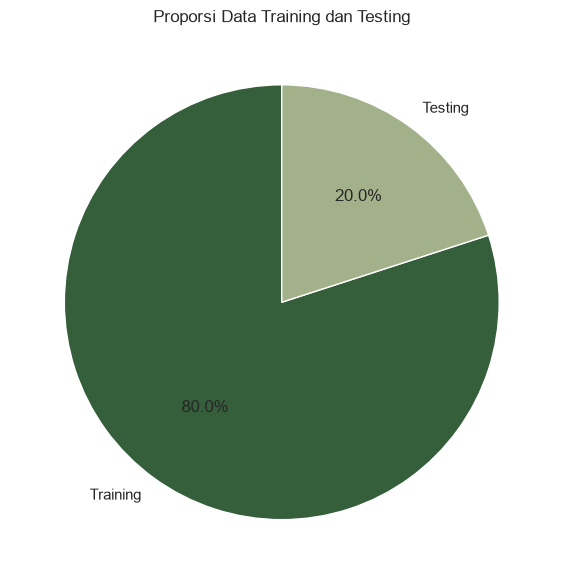

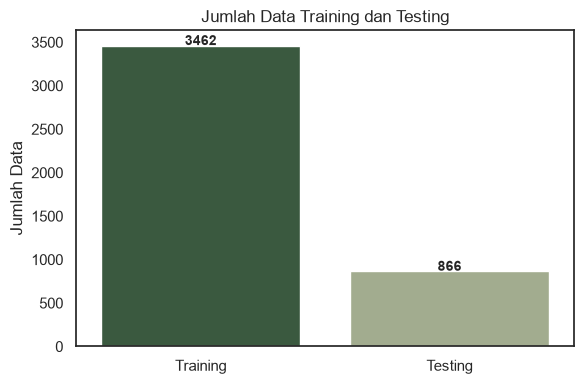

SPLIT DATA BERHASIL


In [30]:
# ==========================================================
# SPLIT DATA TRAINING DAN TESTING + FILTER USIA
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("="*60)
print("SPLIT DATA TRAINING DAN TESTING")
print("="*60)

# ==========================================================
# MEMBACA DATASET
# ==========================================================

df = pd.read_csv("../dataset/developer_burnout_dataset_ervin.csv", delimiter=";")

print(f"Total data awal : {len(df)}")

# ==========================================================
# FILTER USIA 20 - 35 TAHUN
# ==========================================================

df = df[(df["age"] >= 20) & (df["age"] <= 35)].copy()

print(f"Total data setelah filter usia 20-35 tahun : {len(df)}")

# ==========================================================
# SPLIT DATA
# ==========================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("-"*60)
print(f"Data Training : {len(df_train)}")
print(f"Data Testing  : {len(df_test)}")
print("-"*60)

# ==========================================================
# MEMBUAT FOLDER HASIL
# ==========================================================

os.makedirs("../hasil", exist_ok=True)

# ==========================================================
# SIMPAN DATA
# ==========================================================

df_train.to_csv("../hasil/3_data_training.csv", index=False)
df_test.to_csv("../hasil/3_data_testing.csv", index=False)

print("Data training berhasil disimpan")
print("Data testing berhasil disimpan")

# ==========================================================
# GRAFIK PROPORSI TRAIN TEST
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    [len(df_train), len(df_test)],
    labels=["Training","Testing"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#355E3B","#A3B18A"]
)

plt.title("Proporsi Data Training dan Testing")
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIK JUMLAH DATA
# ==========================================================

visual = pd.DataFrame({
    "Jenis Data":["Training","Testing"],
    "Jumlah":[len(df_train),len(df_test)]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=visual,
    x="Jenis Data",
    y="Jumlah",
    hue="Jenis Data",
    palette=["#355E3B","#A3B18A"],
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()+5),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Jumlah Data Training dan Testing")
plt.ylabel("Jumlah Data")
plt.xlabel("")

plt.tight_layout()
plt.show()

print("="*60)
print("SPLIT DATA BERHASIL")
print("="*60)

In [31]:
# ==========================================================
# HANDLING MISSING VALUE
# ==========================================================

import pandas as pd

print("="*60)
print("HANDLING MISSING VALUE")
print("="*60)

# ==========================================================
# CEK MISSING VALUE SEBELUM
# ==========================================================

print("\nMissing Value Data Training")

print(df_train.isnull().sum())

print("\nTotal Missing Value Training :", df_train.isnull().sum().sum())

print("-"*60)

print("\nMissing Value Data Testing")

print(df_test.isnull().sum())

print("\nTotal Missing Value Testing :", df_test.isnull().sum().sum())

# ==========================================================
# HAPUS MISSING VALUE
# ==========================================================

jumlah_train_awal = len(df_train)
jumlah_test_awal = len(df_test)

df_train = df_train.dropna().reset_index(drop=True)
df_test = df_test.dropna().reset_index(drop=True)

# ==========================================================
# HASIL SETELAH HANDLING
# ==========================================================

print("\nJumlah Data Setelah Handling")

print("Training :", len(df_train))
print("Testing  :", len(df_test))

print("-"*60)

print("Data Training yang dihapus :", jumlah_train_awal-len(df_train))
print("Data Testing yang dihapus  :", jumlah_test_awal-len(df_test))

print("-"*60)

print("Total Missing Value Setelah Handling")

print("Training :", df_train.isnull().sum().sum())
print("Testing  :", df_test.isnull().sum().sum())

print("="*60)
print("HANDLING MISSING VALUE SELESAI")
print("="*60)

HANDLING MISSING VALUE

Missing Value Data Training
age                  0
experience_years    85
daily_work_hours    71
sleep_hours         71
caffeine_intake     75
bugs_per_day        66
commits_per_day     64
meetings_per_day    62
screen_time         73
exercise_hours      64
burnout_level       72
dtype: int64

Total Missing Value Training : 703
------------------------------------------------------------

Missing Value Data Testing
age                  0
experience_years    15
daily_work_hours    22
sleep_hours         20
caffeine_intake     18
bugs_per_day        14
commits_per_day     15
meetings_per_day    19
screen_time         15
exercise_hours      23
burnout_level       13
dtype: int64

Total Missing Value Testing : 174

Jumlah Data Setelah Handling
Training : 2819
Testing  : 701
------------------------------------------------------------
Data Training yang dihapus : 643
Data Testing yang dihapus  : 165
------------------------------------------------------------
Total M

In [32]:
# ==========================================================
# NORMALISASI DATA (MIN-MAX SCALING)
# ==========================================================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("NORMALISASI DATA (MIN-MAX SCALING)")
print("="*60)

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

print("\nJumlah Fitur :", X_train.shape[1])

print("Jumlah Data Training :", X_train.shape)

print("Jumlah Data Testing  :", X_test.shape)

print("-"*60)

# ==========================================================
# NORMALISASI
# ==========================================================

scaler = MinMaxScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Normalisasi berhasil dilakukan")

print("-"*60)

# ==========================================================
# GABUNGKAN KEMBALI DENGAN TARGET
# ==========================================================

df_train = X_train.copy()
df_train["burnout_level"] = y_train.reset_index(drop=True)

df_test = X_test.copy()
df_test["burnout_level"] = y_test.reset_index(drop=True)

# ==========================================================
# MENAMPILKAN HASIL
# ==========================================================

print("\nData Training Setelah Normalisasi")

print(df_train.head())

print("-"*60)

print("\nData Testing Setelah Normalisasi")

print(df_test.head())

print("-"*60)

# ==========================================================
# CEK RENTANG NILAI
# ==========================================================

print("Nilai Minimum Training")

print(df_train.drop(columns=["burnout_level"]).min())

print("-"*60)

print("Nilai Maksimum Training")

print(df_train.drop(columns=["burnout_level"]).max())

print("-"*60)

print("Nilai Minimum Testing")

print(df_test.drop(columns=["burnout_level"]).min())

print("-"*60)

print("Nilai Maksimum Testing")

print(df_test.drop(columns=["burnout_level"]).max())

print("="*60)
print("NORMALISASI DATA SELESAI")
print("="*60)

NORMALISASI DATA (MIN-MAX SCALING)

Jumlah Fitur : 10
Jumlah Data Training : (2819, 10)
Jumlah Data Testing  : (701, 10)
------------------------------------------------------------
Normalisasi berhasil dilakukan
------------------------------------------------------------

Data Training Setelah Normalisasi
        age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  0.933333          0.368421          0.609610        0.664         0.000000   
1  0.000000          0.263158          0.848849        0.676         0.285714   
2  0.466667          0.578947          0.294294        0.744         0.285714   
3  0.866667          0.842105          0.641642        0.208         1.000000   
4  0.733333          0.789474          0.416416        0.510         0.714286   

   bugs_per_day  commits_per_day  meetings_per_day  screen_time  \
0      0.210526         1.000000          0.555556     0.617735   
1      0.842105         0.379310          0.444444     0.625186   
2  

In [33]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

import pandas as pd

print("="*60)
print("LABEL ENCODING")
print("="*60)

# ==========================================================
# MAPPING LABEL MANUAL
# ==========================================================

label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

# ==========================================================
# ENCODING TARGET
# ==========================================================

df_train["burnout_level"] = df_train["burnout_level"].map(label_mapping)

df_test["burnout_level"] = df_test["burnout_level"].map(label_mapping)

print("\nLabel Encoding berhasil dilakukan")

print("-"*60)

# ==========================================================
# MENAMPILKAN MAPPING LABEL
# ==========================================================

print("Mapping Label")

for label, kode in label_mapping.items():
    print(f"{label} = {kode}")

print("-"*60)

# ==========================================================
# CEK HASIL ENCODING
# ==========================================================

print("Distribusi Target Training")

print(df_train["burnout_level"].value_counts().sort_index())

print("-"*60)

print("Distribusi Target Testing")

print(df_test["burnout_level"].value_counts().sort_index())

print("-"*60)

# ==========================================================
# MENAMPILKAN DATA
# ==========================================================

print("\nData Training")

print(df_train.head())

print("-"*60)

print("\nData Testing")

print(df_test.head())

print("-"*60)

# ==========================================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X_train = df_train.drop(columns=["burnout_level"])
y_train = df_train["burnout_level"]

X_test = df_test.drop(columns=["burnout_level"])
y_test = df_test["burnout_level"]

print("Ukuran Data Training")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("-"*60)

print("Ukuran Data Testing")

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# VERIFIKASI MAPPING
# ==========================================================

print("Verifikasi Mapping")

print("0 = Low")
print("1 = Medium")
print("2 = High")

print("="*60)
print("LABEL ENCODING SELESAI")
print("="*60)

LABEL ENCODING

Label Encoding berhasil dilakukan
------------------------------------------------------------
Mapping Label
Low = 0
Medium = 1
High = 2
------------------------------------------------------------
Distribusi Target Training
burnout_level
0     663
1    1388
2     768
Name: count, dtype: int64
------------------------------------------------------------
Distribusi Target Testing
burnout_level
0    164
1    387
2    150
Name: count, dtype: int64
------------------------------------------------------------

Data Training
        age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  \
0  0.933333          0.368421          0.609610        0.664         0.000000   
1  0.000000          0.263158          0.848849        0.676         0.285714   
2  0.466667          0.578947          0.294294        0.744         0.285714   
3  0.866667          0.842105          0.641642        0.208         1.000000   
4  0.733333          0.789474          0.416416       

RANDOM FOREST (TANPA SMOTE)

Ukuran Data
X_train : (2819, 10)
y_train : (2819,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------
Model Random Forest berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 77.18%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.79      0.69      0.74       164
      Medium       0.77      0.83      0.80       387
        High       0.76      0.70      0.73       150

    accuracy                           0.77       701
   macro avg       0.77      0.74      0.75       701
weighted avg       0.77      0.77      0.77       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low             113   

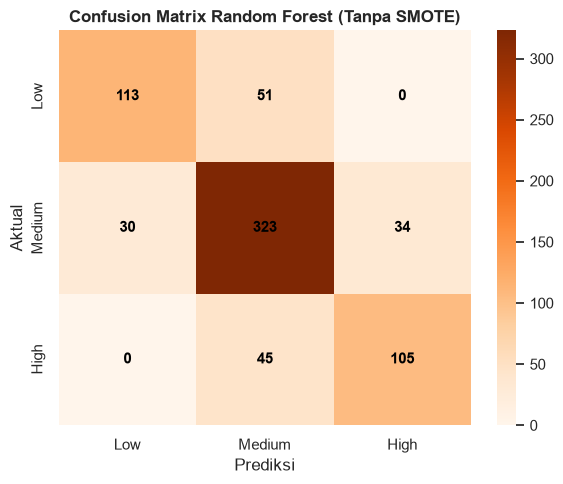

RANDOM FOREST SELESAI


In [34]:
# ==========================================================
# RANDOM FOREST (TANPA SMOTE)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("RANDOM FOREST (TANPA SMOTE)")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# TRAINING
# ==========================================================

rf_model.fit(
    X_train,
    y_train
)

print("Model Random Forest berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_rf = rf_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")
print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix Random Forest (Tanpa SMOTE)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("RANDOM FOREST SELESAI")
print("="*60)

XGBOOST (TANPA SMOTE)

Ukuran Data
X_train : (2819, 10)
y_train : (2819,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------
Model XGBoost berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 79.03%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.79      0.74      0.76       164
      Medium       0.80      0.83      0.81       387
        High       0.77      0.74      0.76       150

    accuracy                           0.79       701
   macro avg       0.79      0.77      0.78       701
weighted avg       0.79      0.79      0.79       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low             121              4

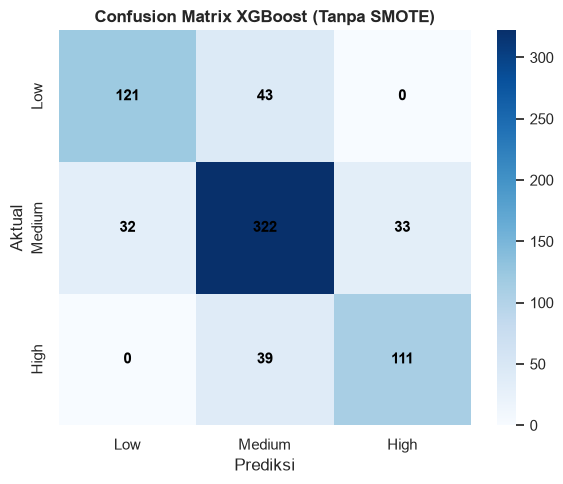

XGBOOST SELESAI


In [35]:
# ==========================================================
# XGBOOST (TANPA SMOTE)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("XGBOOST (TANPA SMOTE)")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# ==========================================================
# TRAINING
# ==========================================================

xgb_model.fit(
    X_train,
    y_train
)

print("Model XGBoost berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_xgb = xgb_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")
print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix XGBoost (Tanpa SMOTE)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("XGBOOST SELESAI")
print("="*60)

SUPPORT VECTOR MACHINE (TANPA SMOTE)

Ukuran Data
X_train : (2819, 10)
y_train : (2819,)
X_test : (701, 10)
y_test : (701,)
------------------------------------------------------------


Model SVM berhasil dilatih
------------------------------------------------------------
Prediksi selesai
------------------------------------------------------------
Accuracy : 83.31%
------------------------------------------------------------
Classification Report

              precision    recall  f1-score   support

         Low       0.84      0.79      0.81       164
      Medium       0.84      0.87      0.85       387
        High       0.82      0.79      0.80       150

    accuracy                           0.83       701
   macro avg       0.83      0.82      0.82       701
weighted avg       0.83      0.83      0.83       701

------------------------------------------------------------
Confusion Matrix

               Predict Low  Predict Medium  Predict High
Actual Low             129              35             0
Actual Medium           24             336            27
Actual High              0              31           119
--------------------------------------------

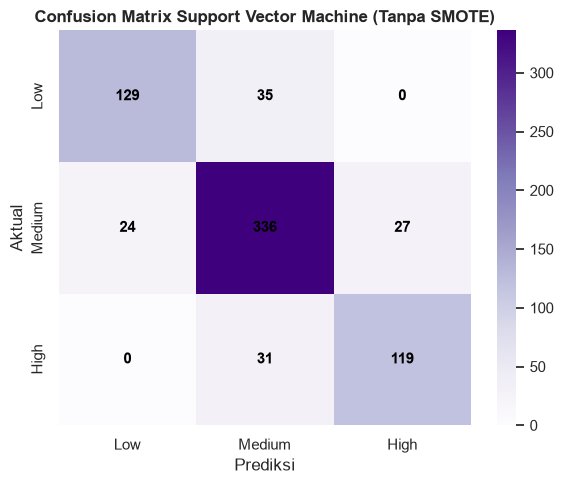

SUPPORT VECTOR MACHINE SELESAI


In [36]:
# ==========================================================
# SUPPORT VECTOR MACHINE (TANPA SMOTE)
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("="*60)
print("SUPPORT VECTOR MACHINE (TANPA SMOTE)")
print("="*60)

# ==========================================================
# CEK UKURAN DATA
# ==========================================================

print("\nUkuran Data")

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("-"*60)

# ==========================================================
# MEMBUAT MODEL
# ==========================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

# ==========================================================
# TRAINING
# ==========================================================

svm_model.fit(
    X_train,
    y_train
)

print("Model SVM berhasil dilatih")

print("-"*60)

# ==========================================================
# PREDIKSI
# ==========================================================

y_pred_svm = svm_model.predict(X_test)

print("Prediksi selesai")

print("-"*60)

# ==========================================================
# AKURASI
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy : {:.2f}%".format(accuracy*100))

print("-"*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

print("-"*60)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Low",
        "Actual Medium",
        "Actual High"
    ],
    columns=[
        "Predict Low",
        "Predict Medium",
        "Predict High"
    ]
)

print("Confusion Matrix\n")
print(cm_df)

print("-"*60)

# ==========================================================
# VISUALISASI CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(6,5))

sns.set_theme(style="white")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    annot_kws={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Confusion Matrix Support Vector Machine (Tanpa SMOTE)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.tight_layout()
plt.show()

print("="*60)
print("SUPPORT VECTOR MACHINE SELESAI")
print("="*60)